<a href="https://colab.research.google.com/github/Indu7777/6thSem-ML-Lab/blob/main/Lab-7-SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IRIS DATASET
Accuracy with linear kernel: 1.0000
Accuracy with RBF kernel: 1.0000

Confusion Matrix (Linear):
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Confusion Matrix (RBF):
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

LETTER RECOGNITION DATASET
Training SVM on letter recognition (RBF kernel, sample of 5000 training samples)...
Accuracy on letter recognition: 0.8800


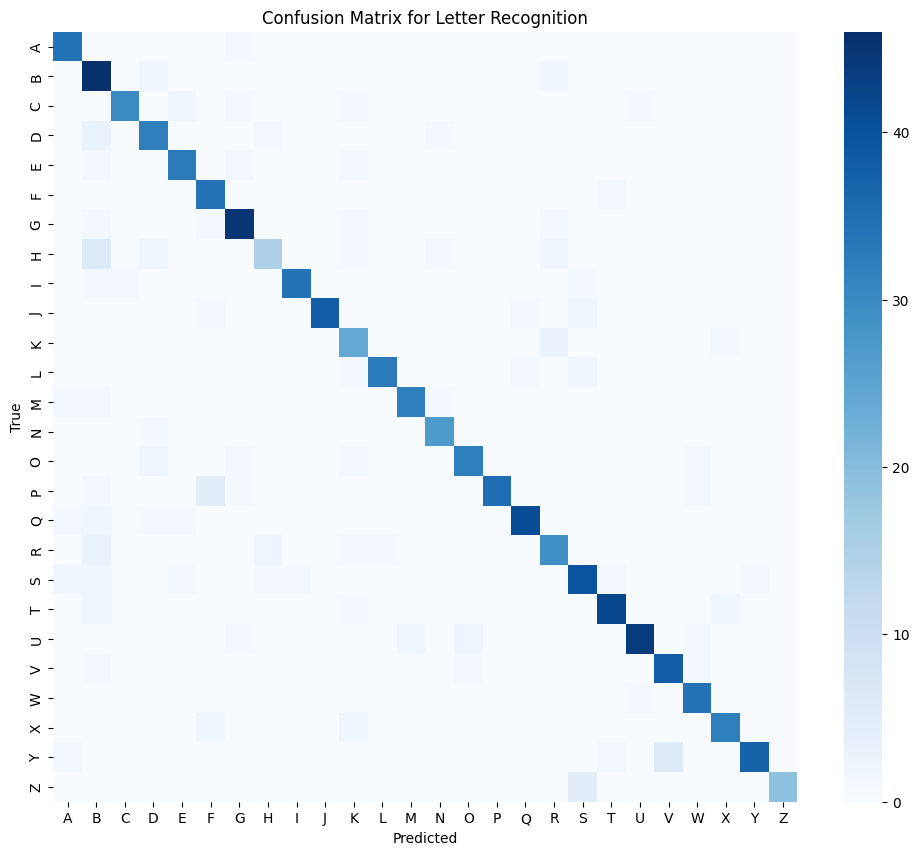


Computing AUC (One-vs-Rest) using linear SVM on a subset...
Average AUC (macro): 0.9006


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("IRIS DATASET")
print("="*50)

iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_linear = SVC(kernel='linear', decision_function_shape='ovo')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy with linear kernel: {acc_linear:.4f}")

svm_rbf = SVC(kernel='rbf', gamma='scale', decision_function_shape='ovo')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy with RBF kernel: {acc_rbf:.4f}")

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("\nConfusion Matrix (Linear):\n", cm_linear)
print("Confusion Matrix (RBF):\n", cm_rbf)

print("\n" + "="*50)
print("LETTER RECOGNITION DATASET")
print("="*50)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
columns = ['letter'] + [f'feature_{i}' for i in range(16)]
data = pd.read_csv(url, header=None, names=columns)

X_letter = data.iloc[:, 1:].values
y_letter = data.iloc[:, 0].values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_letter_encoded = le.fit_transform(y_letter)  # 0-25

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_letter, y_letter_encoded, test_size=0.3, random_state=42)


sample_size = 5000
Xl_train_small = Xl_train[:sample_size]
yl_train_small = yl_train[:sample_size]
Xl_test_small = Xl_test[:1000]
yl_test_small = yl_test[:1000]

print("Training SVM on letter recognition (RBF kernel, sample of 5000 training samples)...")
svm_letter = SVC(kernel='rbf', gamma='scale', decision_function_shape='ovo', random_state=42)
svm_letter.fit(Xl_train_small, yl_train_small)
yl_pred = svm_letter.predict(Xl_test_small)
acc_letter = accuracy_score(yl_test_small, yl_pred)
print(f"Accuracy on letter recognition: {acc_letter:.4f}")

cm_letter = confusion_matrix(yl_test_small, yl_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm_letter, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Letter Recognition')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


print("\nComputing AUC (One-vs-Rest) using linear SVM on a subset...")
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

yl_test_bin = label_binarize(yl_test_small, classes=range(26))
n_classes = yl_test_bin.shape[1]

clf = OneVsRestClassifier(SVC(kernel='linear', probability=False, random_state=42))
clf.fit(Xl_train_small, yl_train_small)
y_score = clf.decision_function(Xl_test_small)

from sklearn.metrics import roc_auc_score
auc_scores = []
for i in range(n_classes):
    auc = roc_auc_score(yl_test_bin[:, i], y_score[:, i])
    auc_scores.append(auc)
print(f"Average AUC (macro): {np.mean(auc_scores):.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')